In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('mnist_train.csv')
t = df.iloc[:, 0] # the labels column
x = df.iloc[:, 1:] # the pixels columns
x_train_val , x_test, y_train_val, y_test = train_test_split(x , t , test_size=0.20, random_state=42 , stratify=t)
# Adding stratify=y ensures the split isn't random in a way that accidentally leaves all the "9s" in the test set

x_train, x_val, y_train, y_val = train_test_split(x_train_val , y_train_val , test_size=0.25, random_state=42 , stratify=y_train_val)

#check the splitting done correctly
print(f"Training shapes: {x_train.shape , y_train.shape}")
print(f"Validation shapes: {x_val.shape , y_val.shape}")
print(f"Testing shapes: {x_test.shape , y_test.shape}")


x_train = x_train/255.0
x_val = x_val/255.0
x_test = x_test/255.0

# Convert to PyTorch tensors el pictures el kter htt2sm batches

train_features = torch.tensor(x_train.values , dtype=torch.float32)
train_labels = torch.tensor(y_train.values , dtype=torch.long)

train_dataset = TensorDataset(train_features, train_labels)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True  # Shuffle the training data 
                              )

val_features = torch.tensor(x_val.values , dtype=torch.float32)
val_labels = torch.tensor(y_val.values , dtype=torch.long)
val_dataset = TensorDataset(val_features, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=64)

test_features = torch.tensor(x_test.values , dtype=torch.float32)
test_labels = torch.tensor(y_test.values , dtype=torch.long)
test_dataset = TensorDataset(test_features, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=64)



Training shapes: ((36000, 784), (36000,))
Validation shapes: ((12000, 784), (12000,))
Testing shapes: ((12000, 784), (12000,))


In [ ]:

class digit_recognition(nn.Module):
    def __init__(self):
        super().__init__()
        # 784 pixel input maps to 128 neuron  to 10 output (digits 0-9)
        # without sequential i have to define each layer separately and call each one to forward pass
        # 2 hidden layers
        self.model = nn.Sequential(
             nn.Linear(784 , 128 ), 
             nn.ReLU(), 
             nn.Linear(128 , 64),
             nn.ReLU(),
             nn.Linear(64 , 32 ),
             nn.ReLU(),
             nn.Linear(32 , 10)
             
         )
        self.loss_fn = nn.CrossEntropyLoss()
        #apply is built in method in torch that applies a function to every layer in the network
        self.apply(self._init_weights_)
         # Dropout layer with 20% dropout rate
    def _init_weights_(self , module):
        if isinstance(module , nn.Linear):
            nn.init.kaiming_normal_(module.weight , mode = 'fan_in' , nonlinearity='relu')
            if module.bias is not None:
             nn.init.zeros_(module.bias)
            
    def forward(self, x):
        return self.model(x)

    def training_step(self , train_dataloader, val_dataloader , epochs, lr = 0.01 ):
        #odel.parameters() contains:
        # Layer 1: Weights (784 x 128) and Biases (128)
        # Layer 2: Weights (128 x 64) and Biases (64)
        # Layer 3: Weights (64 x 32) and Biases (32)
        # Layer 4: Weights (32 x 10) and Biases (10)
    #optimizer = optim.SGD(model.parameters(), lr=0.01)
     
     #loss = nn.CrossEntropyLoss()
     optimizer = optim.SGD(self.parameters(), lr= lr)
     history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
     for epoch in range (epochs) :
         self.train()  # Set the model to training mode to enable droupout percentage
         #When a neural network trains, it tries to minimize loss on the training data.
         # If given enough capacity (layers, neurons), it can do this too well 
         # it starts memorizing specific training examples rather than learning general patterns.
         #Why Overfitting Happens: Co-adaptation
         #The deeper reason is something called co-adaptation. Neurons in a layer start to rely on each other in very specific ways.
         #Imagine neurons A, B, C working together:
         #Neuron A: detects a curve at top
         #Neuron B: detects a gap in middle  
         #Neuron C: always fires to "fix" A's mistakes

         #→ C never learns anything useful on its own
         #→ The trio only works as a unit
         #→ Remove any one of them → whole prediction collapses
         running_loss = 0.0 
         correct_predictions = 0
         total_predictions = 0
         
         for pixels , labels in train_dataloader :
                optimizer.zero_grad()  
                y_hat = self(pixels)  #foward pass
                current_loss = self.loss_fn(y_hat, labels) #compute  training loss
                # this loss is average loss across the batch size 
                current_loss.backward()    # Backpropagation to compute gradients
                optimizer.step()   # Update the weights (Gradient Descent)
                #if current_loss.item() < threshold:
                 #   print(f"Early stopping at epoch {epoch} with loss {current_loss.item()}")
                  #  return
                running_loss += current_loss.item() * labels.size(0)  # Accumulate total loss for whole batch
                #as batches size are not always equal so we need
                #to multiply the average loss by the batch size to get the total loss for that batch
        
              #If you are training a model to recognize digits (0-9), 
              # the output layer has 10 neurons. Each neuron represents one digit.
              # For a single image, the output (y_hat) is a vector of 10 numbers:
              # $$y_{hat} = [ -1.2,  0.5, 6.2, -0.3,  0.1,  0.8,  -2.1,  1.1, 0.0,  -0.5 ]
              # $$The first number (-1.2) corresponds to class 0.
              # The second number (0.5) corresponds to class 1.
              # The third number (6.2) corresponds to class 2 and so on 
              # so y hat will be 10 dimension as 10 neurons in o/p layer * number of images in batch
                predections = y_hat.argmax(dim=1)
                correct_predictions+= (predections==labels).sum().item()
                # assume corrct labels [ 2  3 ,6 ] for 3 images batch
                # and the predections are [ 2  1 ,6 ]
                # what.sum() do is to count how many times the predections are equal to the  labels
                #treating true = 1 [true , false , true ]=> 2  correct predictions
                total_predictions += labels.size(0)  # Total number of predictions made
                #as you may ask yourself why labels.size(0) arenot labels.size() 1 dimension
                #bec it returns object of type tensor and we need to specify the dimension to get integer
         train_loss  = running_loss / total_predictions
         train_accuracy = correct_predictions / total_predictions
         self.eval()
         val_loss_sum, val_correct, val_total = 0.0, 0, 0
 
         with torch.no_grad():                  
            for pixels, labels in val_dataloader:
                y_hat = self(pixels)
                loss  = self.loss_fn(y_hat, labels)
 
                val_loss_sum += loss.item() * labels.size(0)
                preds         = y_hat.argmax(dim=1)
                val_correct  += (preds == labels).sum().item()
                val_total    += labels.size(0)
 
         val_loss = val_loss_sum / val_total
         val_acc  = val_correct  / val_total
         history["train_loss"].append(train_loss)
         history["val_loss"].append(val_loss)
         history["train_acc"].append(train_accuracy)
         history["val_acc"].append(val_acc)
 
     print(f"Epoch {epoch:>2}/{epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")
  
     return history

Epoch 19/20 | Train Loss: 0.0974  Acc: 0.9720 | Val Loss: 0.1477  Acc: 0.9577


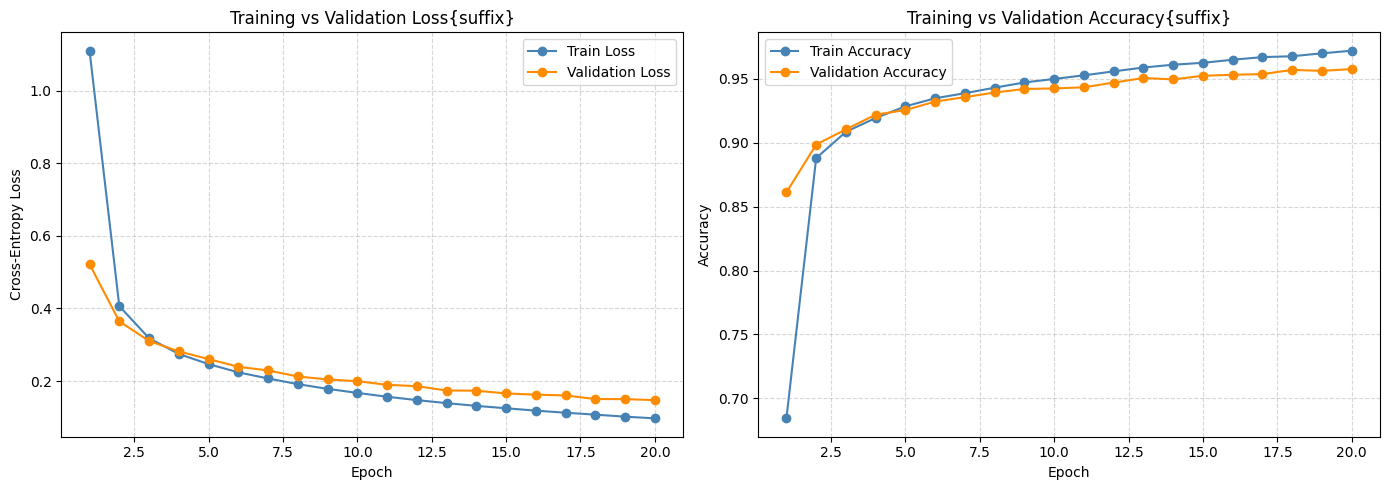

Plot saved → training_curves.png


In [4]:
def plot_history(history , title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Loss plot —
    ax1.plot(epochs, history["train_loss"], label="Train Loss",      color="steelblue",  marker="o")
    ax1.plot(epochs, history["val_loss"],   label="Validation Loss", color="darkorange", marker="o")
    ax1.set_title("Training vs Validation Loss{suffix}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
 
    # — Accuracy plot —
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy",      color="steelblue",  marker="o")
    ax2.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="darkorange", marker="o")
    ax2.set_title("Training vs Validation Accuracy{suffix}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)
 
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → training_curves.png")
 
 
# ─────────────────────────────────────────────
# 6. RUN EVERYTHING
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model   = digit_recognition()
    history = model.training_step( train_dataloader, val_dataloader, epochs=20, lr=0.01)
    plot_history(history )


#Imagine you have 1,000 images and a Batch Size of 100.
#To complete 1 Epoch, the model needs to process 10 Batches.
#This means 1 Epoch = 10 Iterations.

# Analysis

In [13]:
# Model Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score
# evaluates the trained model on unseen test data using: Accuracy & Confusion Matrix
def evaluate_on_test(model, test_loader): 
    y_true = [] # stores actual labels
    y_pred = [] # stores predicted labels
#Dropout is a technique where random neurons are temporarily deactivated during training to prevent overfitting and improve the model’s ability to generalize.
    model.eval() #Disables dropout and training-specific behavior -> عشان اطلع احسن توقع 
    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x)
            preds = outputs.argmax(dim=1) #argmax selects the class with highest score
            # Store results
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())
    # Measures percentage of correct predictions (Accuracy)
    acc = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {acc:.4f}")
    # Shows classification errors between classes
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc

In [14]:
# Analyze how different learning rates affect training performance and convergence.
def experiment_learning_rates(lrs, epochs=10):
    results = {}

    for lr in lrs:
        print(f"\n-Training with LR = {lr}")
        # Initializing a new model ensures fair comparison by starting each experiment from scratch without influence from previous training.
        model = digit_recognition()
        # Train model
        history = model.training_step(train_dataloader, val_dataloader, epochs=epochs, lr=lr)
        plot_history(history)
        final_val_acc = history["val_acc"][-1]  # Store only the final val accuracy for the summary bar chart
        results[lr] = final_val_acc
     # ── Summary bar chart: final val accuracy across all learning rates ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(lr) for lr in lrs], [results[lr] for lr in lrs], color="steelblue")
    plt.title("Final Validation Accuracy vs Learning Rate")
    plt.xlabel("Learning Rate")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, lr in enumerate(lrs):
        plt.text(i, results[lr] + 0.01, f"{results[lr]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Learning Rate Analysis — Insights

- **High LR (0.1):** Converges fastest in the first few epochs but the loss curve tends to oscillate or even diverge because the weight updates overshoot the minimum.
- **Default LR (0.01):** Good balance — steady convergence, stable loss curve, strong final accuracy.
- **Low LR (0.001):** Converges smoothly but more slowly; may need more epochs to reach peak accuracy.
- **Very low LR (0.0001):** Barely moves in 10 epochs — the steps are too tiny. Loss stays high and accuracy lags far behind. This is classic underfitting due to insufficient learning.





-Training with LR = 0.1
Epoch  9/10 | Train Loss: 0.0230  Acc: 0.9934 | Val Loss: 0.1135  Acc: 0.9686


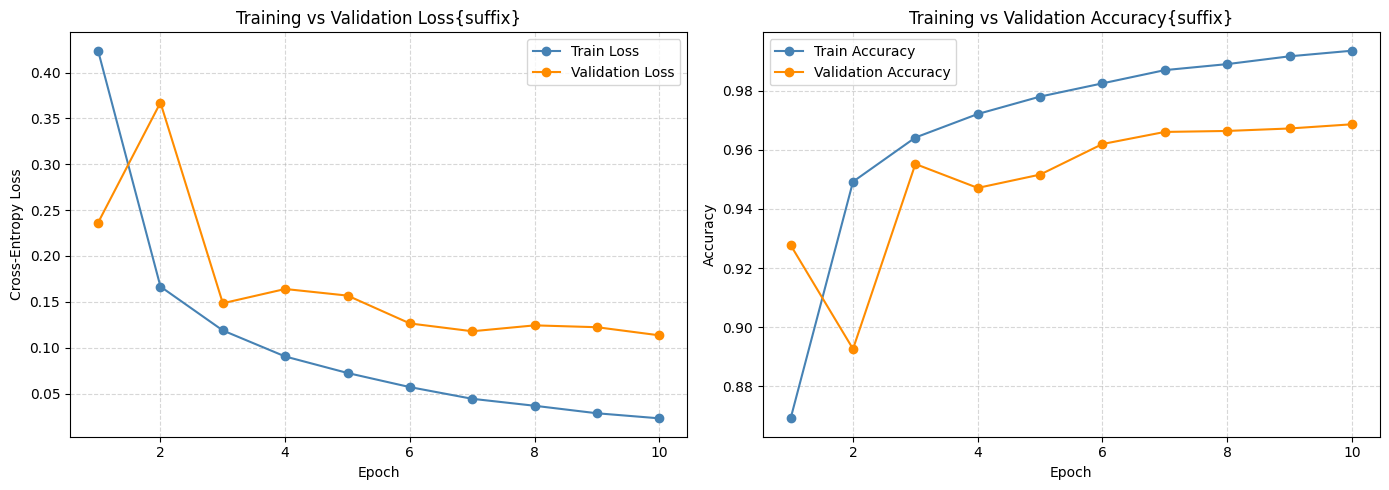

Plot saved → training_curves.png

-Training with LR = 0.01


KeyboardInterrupt: 

In [15]:
lr_results = experiment_learning_rates([0.1, 0.01, 0.001, 0.0001])
print(lr_results)

In [ ]:
# Study how batch size affects training stability and generalization
def experiment_batch_sizes(batch_sizes, epochs=10):
    results = {}

    for bs in batch_sizes:
        print(f"\n-Training with Batch Size = {bs}")

        train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=bs)

        model = digit_recognition()
        history = model.training_step(train_loader, val_loader, epochs=epochs, lr=0.01)
        
        # Full training curves for this batch size
        plot_history(history, title_suffix=f"Batch={bs}")
        final_val_acc = history["val_acc"][-1]
        results[bs] = final_val_acc
     # ── Summary bar chart ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(bs) for bs in batch_sizes], [results[bs] for bs in batch_sizes], color="darkorange")
    plt.title("Final Validation Accuracy vs Batch Size")
    plt.xlabel("Batch Size")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, bs in enumerate(batch_sizes):
        plt.text(i, results[bs] + 0.01, f"{results[bs]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Batch Size Analysis — Insights

- **Small batches (16, 32):** Each gradient update is computed from fewer samples, so the gradient estimate is noisier. This noise acts as implicit regularisation and often leads to better generalisation (higher val accuracy). However, training takes longer per epoch because there are more weight updates.
- **Medium batch (64):** Standard choice — good balance between speed and gradient quality.
- **Large batch (128):** Gradient estimates are very accurate (computed over many samples), so the loss curve is smooth. But the model tends to converge to "sharper" minima that generalise slightly worse. Each epoch is also faster because there are fewer updates.




-Training with Batch Size = 16
Epoch  9/10 | Train Loss: 0.0587  Acc: 0.9827 | Val Loss: 0.1172  Acc: 0.9658


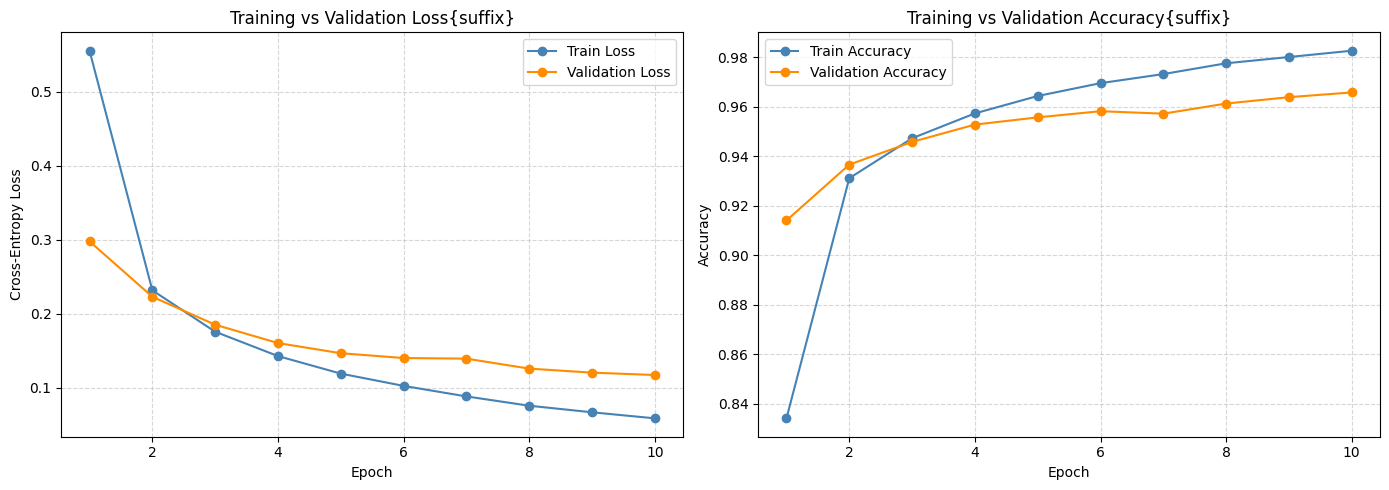

Plot saved → training_curves.png

-Training with Batch Size = 32
Epoch  9/10 | Train Loss: 0.1039  Acc: 0.9698 | Val Loss: 0.1483  Acc: 0.9569


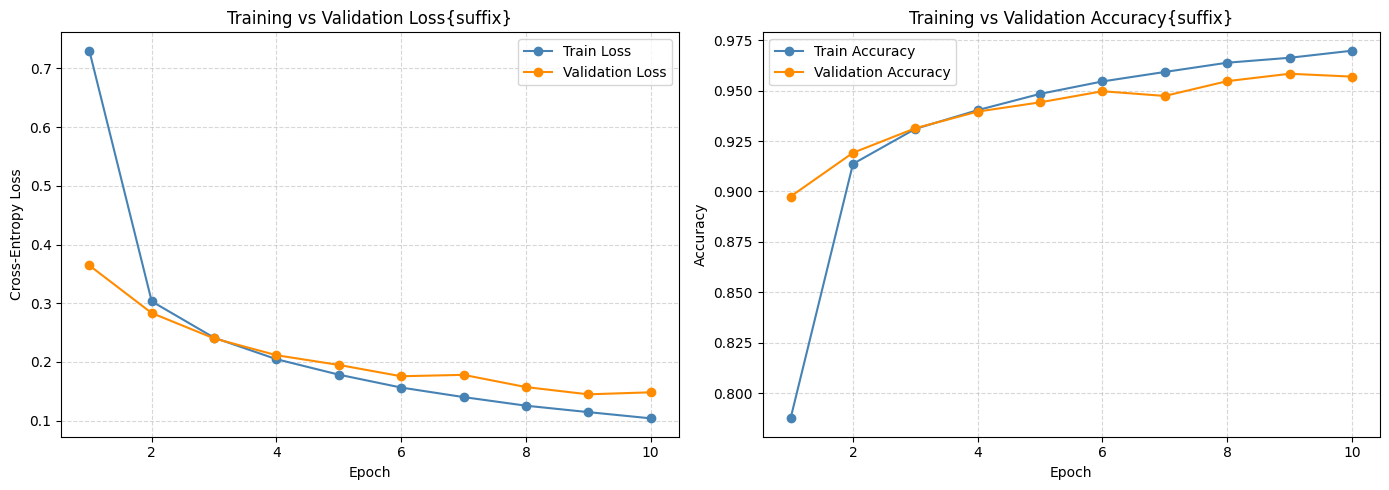

Plot saved → training_curves.png

-Training with Batch Size = 64
Epoch  9/10 | Train Loss: 0.1524  Acc: 0.9559 | Val Loss: 0.1832  Acc: 0.9479


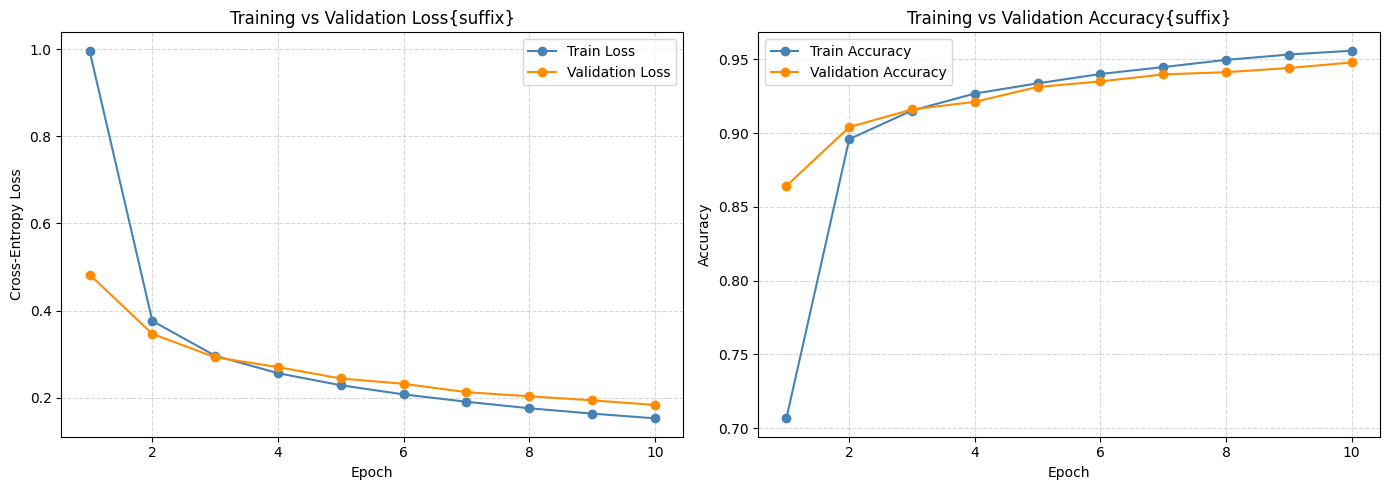

Plot saved → training_curves.png

-Training with Batch Size = 128
Epoch  9/10 | Train Loss: 0.2389  Acc: 0.9314 | Val Loss: 0.2603  Acc: 0.9251


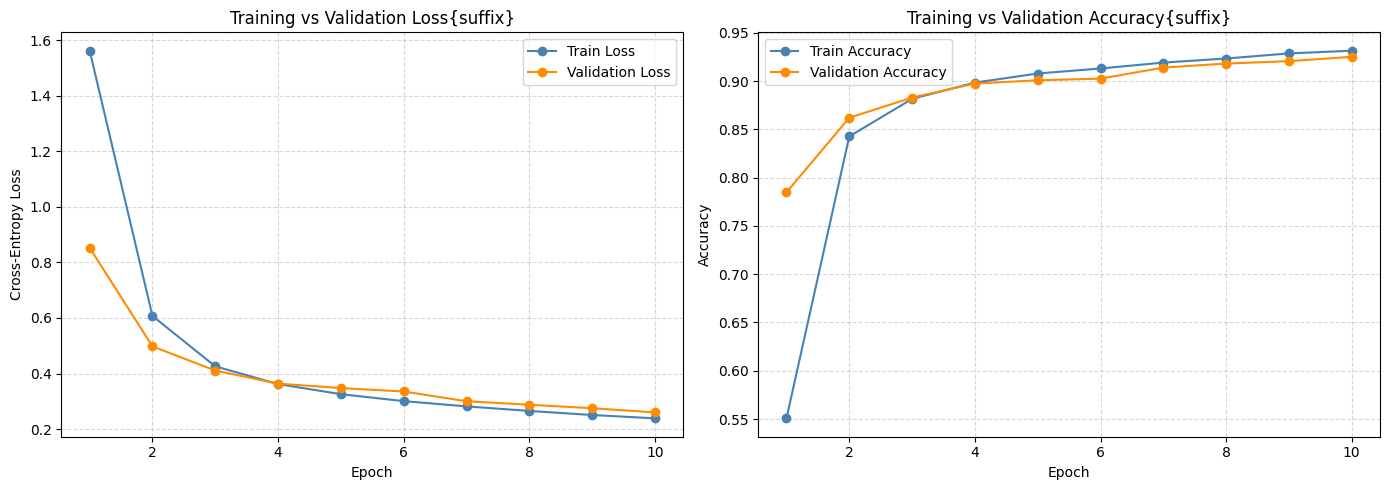

Plot saved → training_curves.png


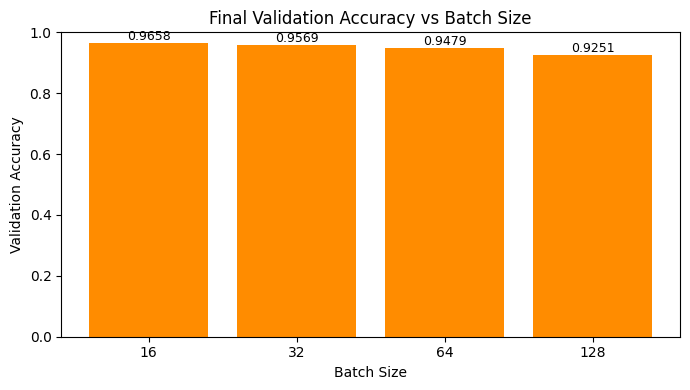

{16: 0.9658333333333333, 32: 0.9569166666666666, 64: 0.9479166666666666, 128: 0.9250833333333334}


In [ ]:
bs_results = experiment_batch_sizes([16, 32, 64, 128])
print(bs_results)


--- Architecture: [64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.2971  Acc: 0.1220 | Val Loss: 2.2731  Acc: 0.1128
Epoch  1/10 | Train Loss: 2.2154  Acc: 0.1823 | Val Loss: 2.1039  Acc: 0.2869
Epoch  2/10 | Train Loss: 1.7347  Acc: 0.4303 | Val Loss: 1.2761  Acc: 0.5897
Epoch  3/10 | Train Loss: 0.9568  Acc: 0.6982 | Val Loss: 0.7538  Acc: 0.7565
Epoch  4/10 | Train Loss: 0.6170  Acc: 0.8107 | Val Loss: 0.5441  Acc: 0.8388
Epoch  5/10 | Train Loss: 0.4826  Acc: 0.8577 | Val Loss: 0.4932  Acc: 0.8519
Epoch  6/10 | Train Loss: 0.4244  Acc: 0.8784 | Val Loss: 0.4259  Acc: 0.8721
Epoch  7/10 | Train Loss: 0.3894  Acc: 0.8884 | Val Loss: 0.3908  Acc: 0.8882
Epoch  8/10 | Train Loss: 0.3620  Acc: 0.8978 | Val Loss: 0.3643  Acc: 0.8972
Epoch  9/10 | Train Loss: 0.3362  Acc: 0.9056 | Val Loss: 0.3506  Acc: 0.8976


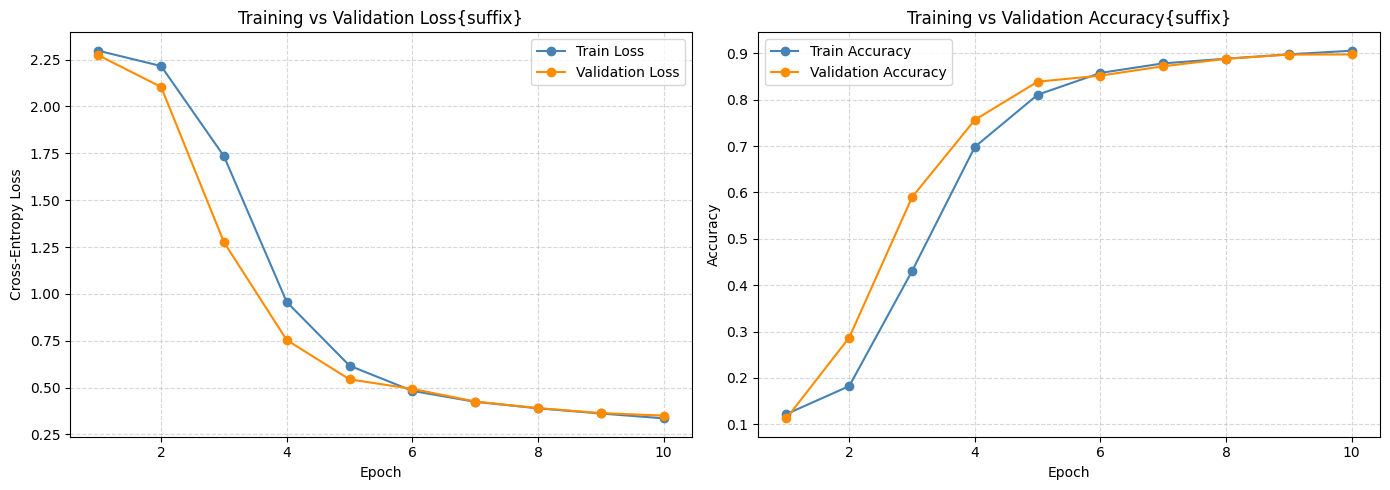

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2870  Acc: 0.1484 | Val Loss: 2.2533  Acc: 0.2738
Epoch  1/10 | Train Loss: 2.0801  Acc: 0.4828 | Val Loss: 1.6551  Acc: 0.5833
Epoch  2/10 | Train Loss: 1.0567  Acc: 0.6979 | Val Loss: 0.7448  Acc: 0.7766
Epoch  3/10 | Train Loss: 0.6284  Acc: 0.8100 | Val Loss: 0.5609  Acc: 0.8358
Epoch  4/10 | Train Loss: 0.4989  Acc: 0.8548 | Val Loss: 0.4784  Acc: 0.8566
Epoch  5/10 | Train Loss: 0.4314  Acc: 0.8750 | Val Loss: 0.4289  Acc: 0.8772
Epoch  6/10 | Train Loss: 0.3930  Acc: 0.8851 | Val Loss: 0.3949  Acc: 0.8857
Epoch  7/10 | Train Loss: 0.3632  Acc: 0.8946 | Val Loss: 0.3681  Acc: 0.8948
Epoch  8/10 | Train Loss: 0.3376  Acc: 0.9031 | Val Loss: 0.3433  Acc: 0.8991
Epoch  9/10 | Train Loss: 0.3151  Acc: 0.9083 | Val Loss: 0.3242  Acc: 0.9069


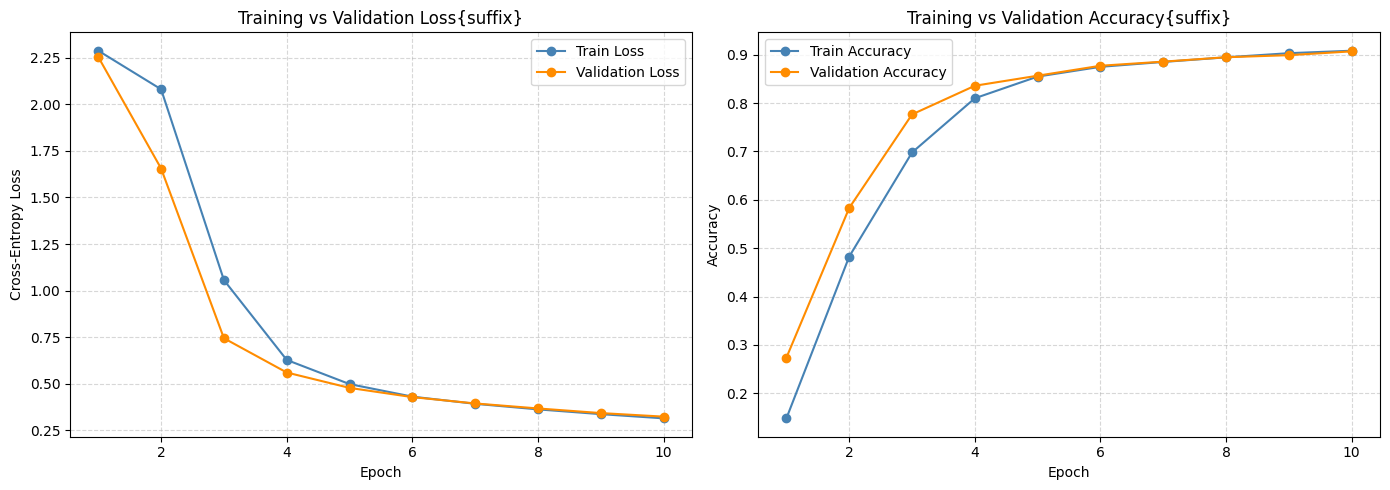

Plot saved → training_curves.png

--- Architecture: [256, 128, 64] ---
Epoch  0/10 | Train Loss: 2.2789  Acc: 0.1733 | Val Loss: 2.2332  Acc: 0.4077
Epoch  1/10 | Train Loss: 1.9699  Acc: 0.5008 | Val Loss: 1.4213  Acc: 0.6428
Epoch  2/10 | Train Loss: 0.9278  Acc: 0.7380 | Val Loss: 0.6866  Acc: 0.7923
Epoch  3/10 | Train Loss: 0.5779  Acc: 0.8270 | Val Loss: 0.5167  Acc: 0.8477
Epoch  4/10 | Train Loss: 0.4575  Acc: 0.8659 | Val Loss: 0.4405  Acc: 0.8718
Epoch  5/10 | Train Loss: 0.4036  Acc: 0.8815 | Val Loss: 0.4074  Acc: 0.8815
Epoch  6/10 | Train Loss: 0.3672  Acc: 0.8940 | Val Loss: 0.3664  Acc: 0.8938
Epoch  7/10 | Train Loss: 0.3389  Acc: 0.9021 | Val Loss: 0.3432  Acc: 0.9011
Epoch  8/10 | Train Loss: 0.3145  Acc: 0.9092 | Val Loss: 0.3373  Acc: 0.9024
Epoch  9/10 | Train Loss: 0.2939  Acc: 0.9147 | Val Loss: 0.3132  Acc: 0.9112


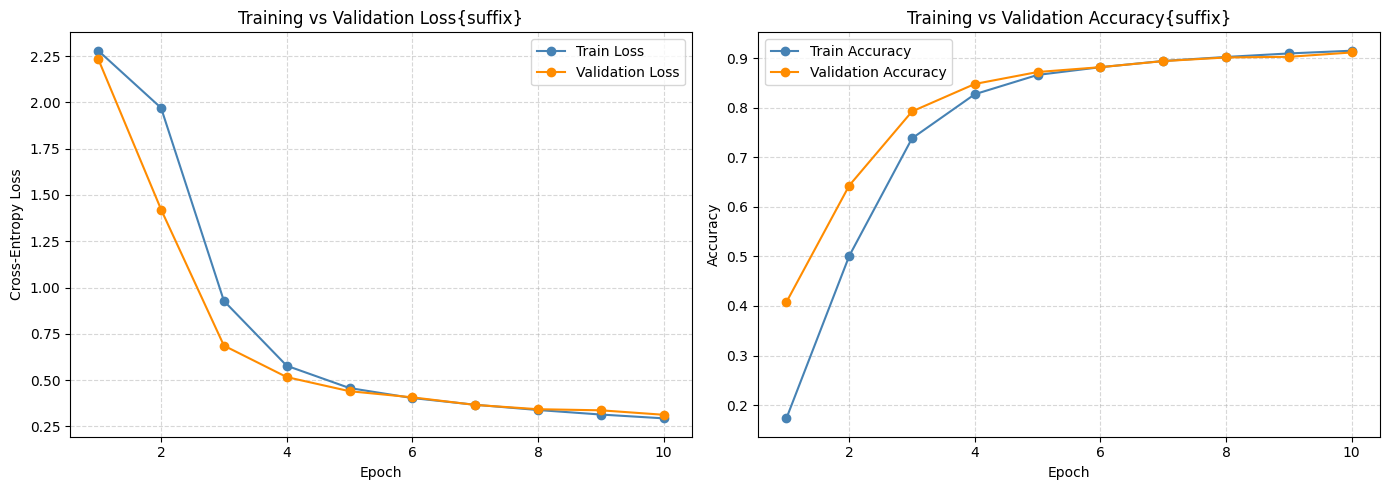

Plot saved → training_curves.png

--- Architecture: [512, 256, 128] ---
Epoch  0/10 | Train Loss: 2.2802  Acc: 0.2442 | Val Loss: 2.2386  Acc: 0.5182
Epoch  1/10 | Train Loss: 1.9553  Acc: 0.5238 | Val Loss: 1.3821  Acc: 0.6351
Epoch  2/10 | Train Loss: 0.9144  Acc: 0.7516 | Val Loss: 0.6521  Acc: 0.8123
Epoch  3/10 | Train Loss: 0.5430  Acc: 0.8438 | Val Loss: 0.4879  Acc: 0.8589
Epoch  4/10 | Train Loss: 0.4349  Acc: 0.8762 | Val Loss: 0.4192  Acc: 0.8774
Epoch  5/10 | Train Loss: 0.3837  Acc: 0.8898 | Val Loss: 0.3859  Acc: 0.8882
Epoch  6/10 | Train Loss: 0.3509  Acc: 0.8998 | Val Loss: 0.3560  Acc: 0.9003
Epoch  7/10 | Train Loss: 0.3259  Acc: 0.9064 | Val Loss: 0.3357  Acc: 0.9047
Epoch  8/10 | Train Loss: 0.3048  Acc: 0.9119 | Val Loss: 0.3136  Acc: 0.9107
Epoch  9/10 | Train Loss: 0.2862  Acc: 0.9182 | Val Loss: 0.2967  Acc: 0.9163


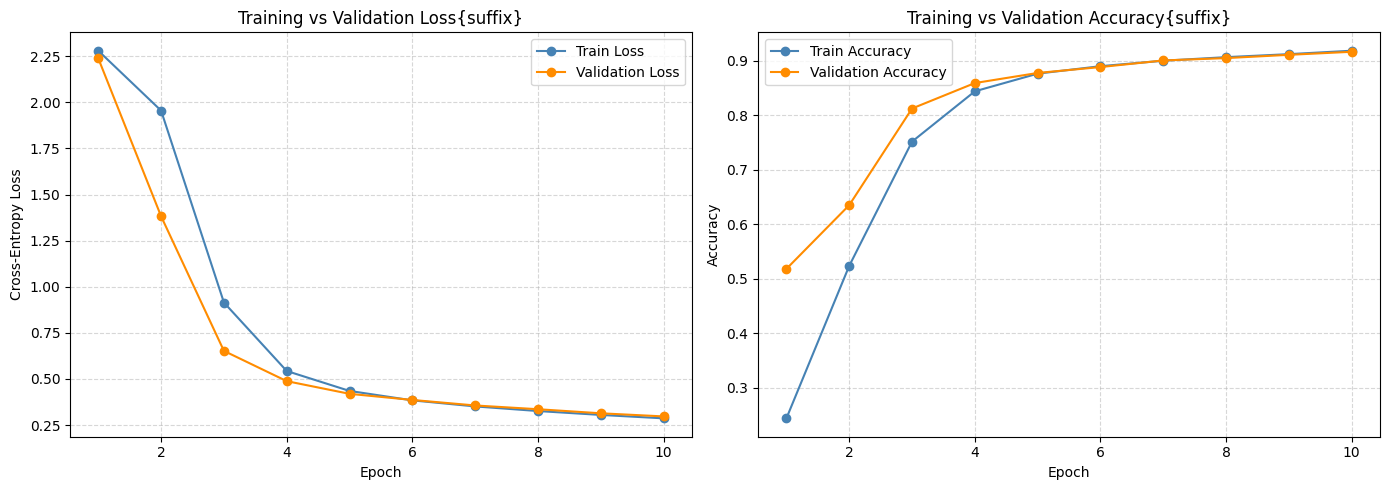

Plot saved → training_curves.png


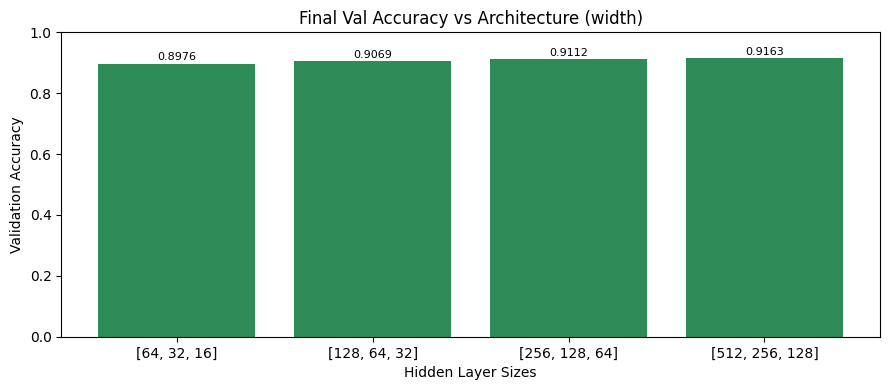

Width results: {'[64, 32, 16]': 0.8975833333333333, '[128, 64, 32]': 0.9069166666666667, '[256, 128, 64]': 0.9111666666666667, '[512, 256, 128]': 0.91625}

--- Architecture: [128] ---
Epoch  0/10 | Train Loss: 1.6237  Acc: 0.6452 | Val Loss: 0.9359  Acc: 0.8109
Epoch  1/10 | Train Loss: 0.6930  Acc: 0.8407 | Val Loss: 0.5641  Acc: 0.8593
Epoch  2/10 | Train Loss: 0.4935  Acc: 0.8737 | Val Loss: 0.4606  Acc: 0.8788
Epoch  3/10 | Train Loss: 0.4205  Acc: 0.8874 | Val Loss: 0.4114  Acc: 0.8862
Epoch  4/10 | Train Loss: 0.3816  Acc: 0.8948 | Val Loss: 0.3819  Acc: 0.8916
Epoch  5/10 | Train Loss: 0.3567  Acc: 0.8996 | Val Loss: 0.3624  Acc: 0.8961
Epoch  6/10 | Train Loss: 0.3383  Acc: 0.9043 | Val Loss: 0.3490  Acc: 0.8997
Epoch  7/10 | Train Loss: 0.3242  Acc: 0.9081 | Val Loss: 0.3352  Acc: 0.9026
Epoch  8/10 | Train Loss: 0.3124  Acc: 0.9111 | Val Loss: 0.3262  Acc: 0.9067
Epoch  9/10 | Train Loss: 0.3019  Acc: 0.9144 | Val Loss: 0.3171  Acc: 0.9088


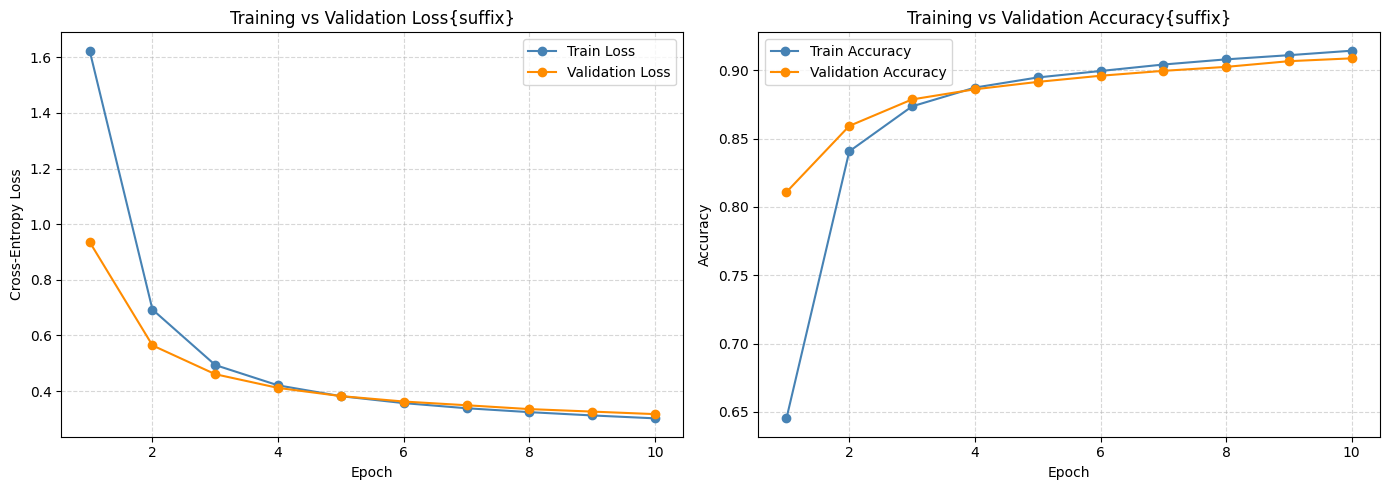

Plot saved → training_curves.png

--- Architecture: [128, 64] ---
Epoch  0/10 | Train Loss: 2.0947  Acc: 0.4056 | Val Loss: 1.6567  Acc: 0.6607
Epoch  1/10 | Train Loss: 1.0231  Acc: 0.7895 | Val Loss: 0.6567  Acc: 0.8319
Epoch  2/10 | Train Loss: 0.5350  Acc: 0.8588 | Val Loss: 0.4742  Acc: 0.8679
Epoch  3/10 | Train Loss: 0.4233  Acc: 0.8831 | Val Loss: 0.4080  Acc: 0.8854
Epoch  4/10 | Train Loss: 0.3740  Acc: 0.8946 | Val Loss: 0.3745  Acc: 0.8908
Epoch  5/10 | Train Loss: 0.3451  Acc: 0.9016 | Val Loss: 0.3490  Acc: 0.8973
Epoch  6/10 | Train Loss: 0.3248  Acc: 0.9061 | Val Loss: 0.3319  Acc: 0.9037
Epoch  7/10 | Train Loss: 0.3090  Acc: 0.9102 | Val Loss: 0.3206  Acc: 0.9067
Epoch  8/10 | Train Loss: 0.2947  Acc: 0.9146 | Val Loss: 0.3079  Acc: 0.9121
Epoch  9/10 | Train Loss: 0.2830  Acc: 0.9181 | Val Loss: 0.2985  Acc: 0.9131


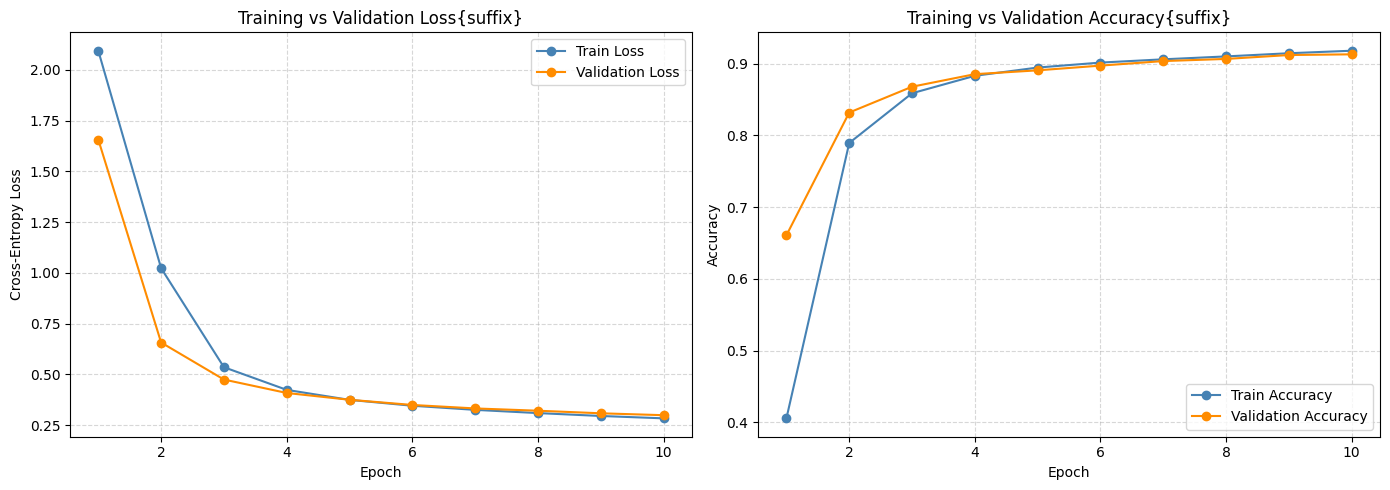

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2891  Acc: 0.1266 | Val Loss: 2.2680  Acc: 0.1844
Epoch  1/10 | Train Loss: 2.1780  Acc: 0.3478 | Val Loss: 1.9737  Acc: 0.4589
Epoch  2/10 | Train Loss: 1.3966  Acc: 0.6178 | Val Loss: 0.8871  Acc: 0.7513
Epoch  3/10 | Train Loss: 0.6795  Acc: 0.8060 | Val Loss: 0.5622  Acc: 0.8353
Epoch  4/10 | Train Loss: 0.4974  Acc: 0.8575 | Val Loss: 0.4653  Acc: 0.8651
Epoch  5/10 | Train Loss: 0.4303  Acc: 0.8766 | Val Loss: 0.4183  Acc: 0.8792
Epoch  6/10 | Train Loss: 0.3893  Acc: 0.8882 | Val Loss: 0.3916  Acc: 0.8885
Epoch  7/10 | Train Loss: 0.3590  Acc: 0.8957 | Val Loss: 0.3608  Acc: 0.8987
Epoch  8/10 | Train Loss: 0.3331  Acc: 0.9042 | Val Loss: 0.3404  Acc: 0.9021
Epoch  9/10 | Train Loss: 0.3106  Acc: 0.9107 | Val Loss: 0.3170  Acc: 0.9085


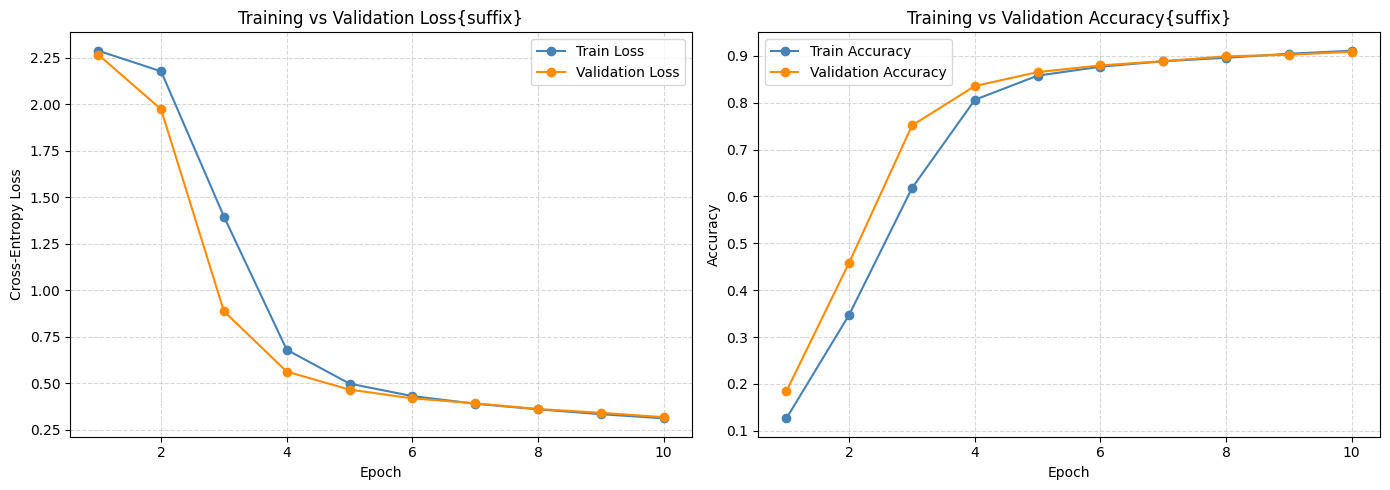

Plot saved → training_curves.png

--- Architecture: [128, 64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.3091  Acc: 0.1008 | Val Loss: 2.3021  Acc: 0.0987
Epoch  1/10 | Train Loss: 2.2983  Acc: 0.1379 | Val Loss: 2.2944  Acc: 0.2211
Epoch  2/10 | Train Loss: 2.2881  Acc: 0.2236 | Val Loss: 2.2787  Acc: 0.2012
Epoch  3/10 | Train Loss: 2.2408  Acc: 0.2401 | Val Loss: 2.1536  Acc: 0.2807
Epoch  4/10 | Train Loss: 1.9447  Acc: 0.3509 | Val Loss: 1.6268  Acc: 0.4076
Epoch  5/10 | Train Loss: 1.2548  Acc: 0.5500 | Val Loss: 1.0833  Acc: 0.6200
Epoch  6/10 | Train Loss: 0.9777  Acc: 0.6595 | Val Loss: 0.9526  Acc: 0.6844
Epoch  7/10 | Train Loss: 0.8573  Acc: 0.7178 | Val Loss: 0.8140  Acc: 0.7443
Epoch  8/10 | Train Loss: 0.7121  Acc: 0.7808 | Val Loss: 0.6555  Acc: 0.8017
Epoch  9/10 | Train Loss: 0.5809  Acc: 0.8248 | Val Loss: 0.5512  Acc: 0.8332


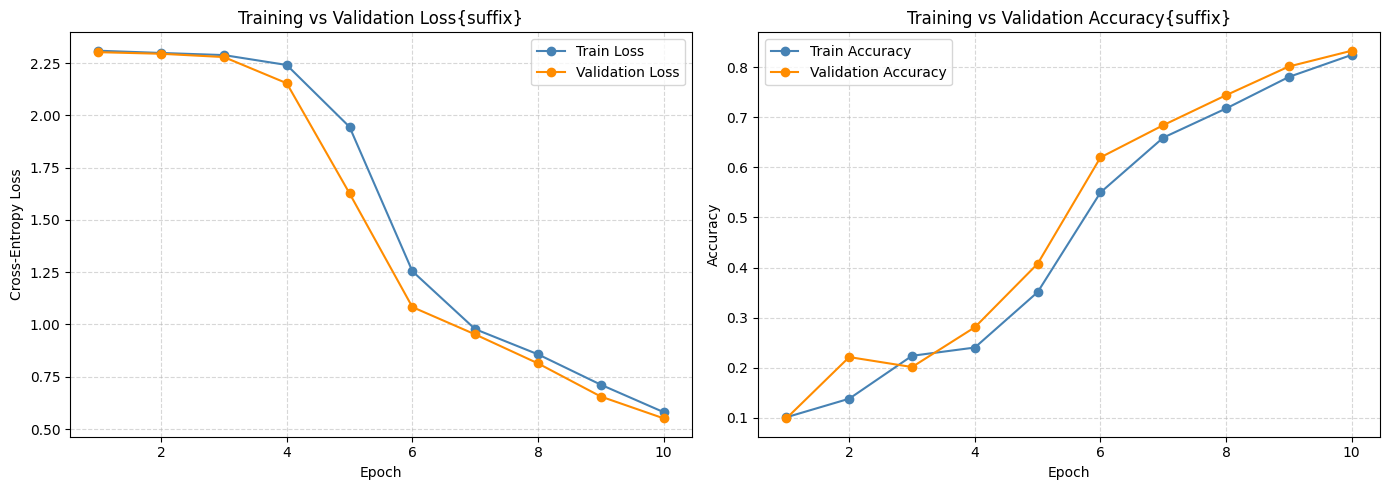

Plot saved → training_curves.png


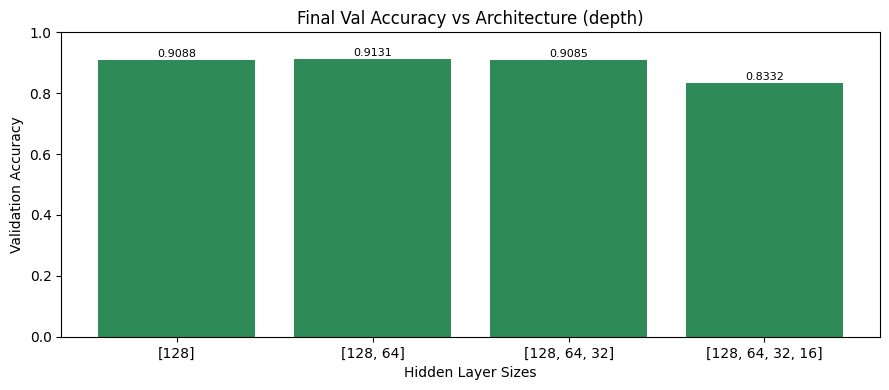

Depth results: {'[128]': 0.9088333333333334, '[128, 64]': 0.9130833333333334, '[128, 64, 32]': 0.9085, '[128, 64, 32, 16]': 0.8331666666666667}


In [ ]:
# Evaluate the impact of changing both neuron count and number of layers.
#
# CustomNet now accepts a list of hidden sizes of any length, so we can test
# both different widths (neuron counts) and different depths (number of layers)
# in the same class without any changes.

class CustomNet(nn.Module):
    def __init__(self, hidden_sizes):
        """
        hidden_sizes : list of ints, e.g. [128, 64, 32]
                       → builds one hidden layer per element, then a 10-class output.
        """
        super().__init__()
        layers = []
        in_size = 784
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, 10))   # output layer
        self.model    = nn.Sequential(*layers)
        self.loss_fn  = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, train_loader, val_loader, epochs, lr=0.01):
        optimizer = optim.SGD(self.parameters(), lr=lr)
        # ← now tracks ALL 4 metrics so plot_history() works correctly
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        for epoch in range(epochs):
            # ── Training phase ──
            self.train()
            running_loss, correct, total = 0.0, 0, 0
            for x, y in train_loader:
                optimizer.zero_grad()
                out  = self(x)
                loss = self.loss_fn(out, y)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * y.size(0)
                correct      += (out.argmax(dim=1) == y).sum().item()
                total        += y.size(0)
            train_loss = running_loss / total
            train_acc  = correct / total

            # ── Validation phase ──
            self.eval()
            val_loss_sum, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for x, y in val_loader:
                    out  = self(x)
                    loss = self.loss_fn(out, y)
                    val_loss_sum += loss.item() * y.size(0)
                    val_correct  += (out.argmax(dim=1) == y).sum().item()
                    val_total    += y.size(0)
            val_loss = val_loss_sum / val_total
            val_acc  = val_correct  / val_total

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            print(f"Epoch {epoch:>2}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        return history


# ── Experiment A: vary neuron WIDTH (keep depth fixed at 3 hidden layers) ──
def experiment_neurons(configs, label="neurons"):
    results = {}
    for sizes in configs:
        label_str = str(sizes)
        print(f"\n--- Architecture: {label_str} ---")
        model = CustomNet(list(sizes))
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)
        plot_history(history, title_suffix=f"Arch {label_str}")
        results[str(sizes)] = history["val_acc"][-1]

    # Summary bar chart
    plt.figure(figsize=(9, 4))
    plt.bar(list(results.keys()), list(results.values()), color="seagreen")
    plt.title(f"Final Val Accuracy vs Architecture ({label})")
    plt.xlabel("Hidden Layer Sizes")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, (k, v) in enumerate(results.items()):
        plt.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()
    return results


# ── Neuron width experiment (depth = 3 hidden layers, width changes) ──
width_configs = [
    [64,  32,  16],
    [128, 64,  32],
    [256, 128, 64],
    [512, 256, 128],
]
width_results = experiment_neurons(width_configs, label="width")
print("Width results:", width_results)


# ── Depth experiment (width ≈ fixed ~128, number of hidden layers changes) ──
depth_configs = [
    [128],                    # 1 hidden layer
    [128, 64],                # 2 hidden layers
    [128, 64, 32],            # 3 hidden layers
    [128, 64, 32, 16],        # 4 hidden layers
]
depth_results = experiment_neurons(depth_configs, label="depth")
print("Depth results:", depth_results)


## Architecture Analysis — Insights

### Neuron Width (fixed 3 layers, changing neuron count)
- **Narrow networks [64,32,16]:** Limited capacity → underfits slightly; the bottleneck at 16 neurons before the output forces too much compression.
- **Medium [128,64,32]:** Usually the sweet spot on MNIST — enough capacity without wasting computation.
- **Wide [256,128,64] and [512,256,128]:** Marginal or no improvement over medium on MNIST because the task is not complex enough to need that many parameters. Training may also be slightly slower.

### Network Depth (fixed width ≈128, changing number of layers)
- **1 hidden layer:** Can still reach decent accuracy on MNIST (it is a simple dataset), but it misses some feature hierarchies.
- **2–3 hidden layers:** Better feature abstraction; generally higher accuracy.
- **4 hidden layers:** On simple tasks like MNIST, very deep networks with SGD can sometimes train slower because gradients weaken as they travel back through many layers (vanishing gradient). ReLU helps, but it does not fully eliminate the issue.




Increasing neurons improves performance slightly

MNIST is simple → large networks not necessary


--- Architecture: [64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.2949  Acc: 0.1874 | Val Loss: 2.2687  Acc: 0.2108
Epoch  1/10 | Train Loss: 2.1692  Acc: 0.2503 | Val Loss: 1.9547  Acc: 0.3792
Epoch  2/10 | Train Loss: 1.5042  Acc: 0.5523 | Val Loss: 1.0761  Acc: 0.6802
Epoch  3/10 | Train Loss: 0.8455  Acc: 0.7571 | Val Loss: 0.6837  Acc: 0.8070
Epoch  4/10 | Train Loss: 0.5704  Acc: 0.8390 | Val Loss: 0.5373  Acc: 0.8388
Epoch  5/10 | Train Loss: 0.4692  Acc: 0.8659 | Val Loss: 0.4556  Acc: 0.8683
Epoch  6/10 | Train Loss: 0.4168  Acc: 0.8825 | Val Loss: 0.4102  Acc: 0.8822
Epoch  7/10 | Train Loss: 0.3801  Acc: 0.8910 | Val Loss: 0.3790  Acc: 0.8913
Epoch  8/10 | Train Loss: 0.3521  Acc: 0.8986 | Val Loss: 0.3601  Acc: 0.8956
Epoch  9/10 | Train Loss: 0.3279  Acc: 0.9055 | Val Loss: 0.3468  Acc: 0.8990


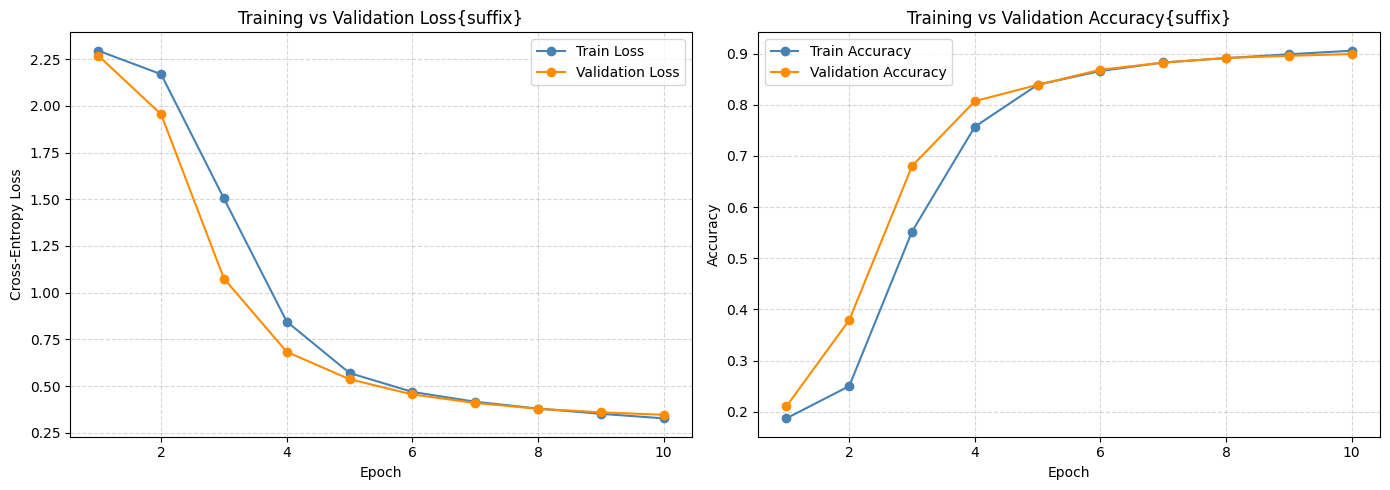

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2865  Acc: 0.1342 | Val Loss: 2.2571  Acc: 0.2424
Epoch  1/10 | Train Loss: 2.0883  Acc: 0.3724 | Val Loss: 1.6743  Acc: 0.4968
Epoch  2/10 | Train Loss: 1.1352  Acc: 0.6750 | Val Loss: 0.7758  Acc: 0.7651
Epoch  3/10 | Train Loss: 0.6334  Acc: 0.8083 | Val Loss: 0.5561  Acc: 0.8349
Epoch  4/10 | Train Loss: 0.5054  Acc: 0.8516 | Val Loss: 0.4858  Acc: 0.8600
Epoch  5/10 | Train Loss: 0.4472  Acc: 0.8715 | Val Loss: 0.4383  Acc: 0.8727
Epoch  6/10 | Train Loss: 0.4079  Acc: 0.8831 | Val Loss: 0.4041  Acc: 0.8839
Epoch  7/10 | Train Loss: 0.3761  Acc: 0.8924 | Val Loss: 0.3739  Acc: 0.8932
Epoch  8/10 | Train Loss: 0.3481  Acc: 0.9004 | Val Loss: 0.3616  Acc: 0.8940
Epoch  9/10 | Train Loss: 0.3222  Acc: 0.9077 | Val Loss: 0.3372  Acc: 0.9039


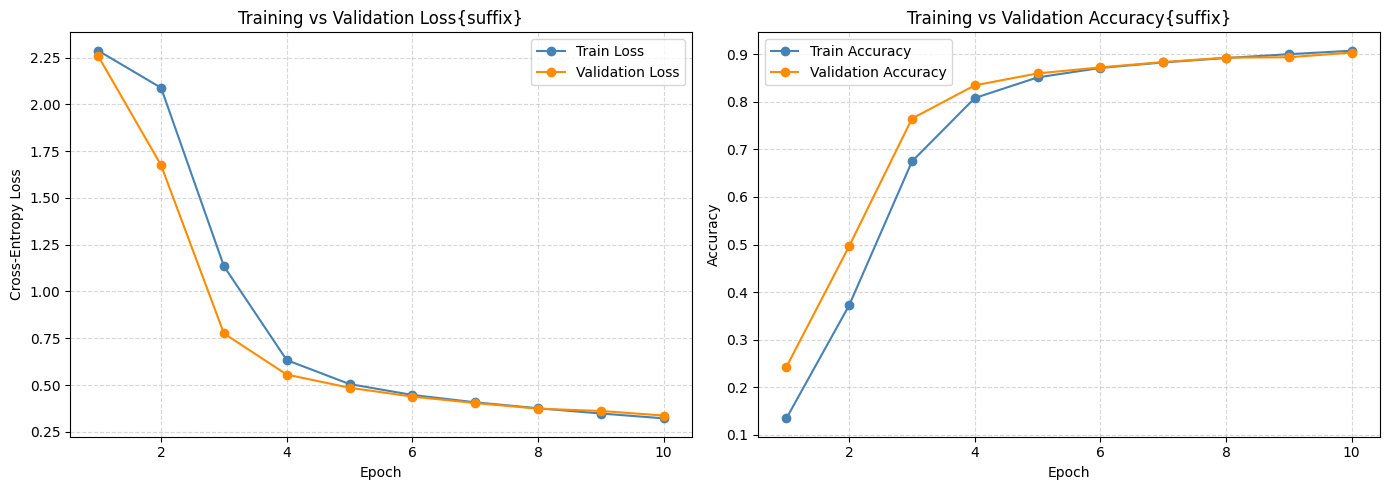

Plot saved → training_curves.png

--- Architecture: [256, 128, 64] ---
Epoch  0/10 | Train Loss: 2.2765  Acc: 0.2825 | Val Loss: 2.2281  Acc: 0.4283
Epoch  1/10 | Train Loss: 1.9461  Acc: 0.4325 | Val Loss: 1.4422  Acc: 0.5789
Epoch  2/10 | Train Loss: 0.9941  Acc: 0.7310 | Val Loss: 0.6899  Acc: 0.8071
Epoch  3/10 | Train Loss: 0.5550  Acc: 0.8445 | Val Loss: 0.4991  Acc: 0.8590
Epoch  4/10 | Train Loss: 0.4374  Acc: 0.8768 | Val Loss: 0.4225  Acc: 0.8806
Epoch  5/10 | Train Loss: 0.3873  Acc: 0.8904 | Val Loss: 0.3865  Acc: 0.8922
Epoch  6/10 | Train Loss: 0.3562  Acc: 0.8987 | Val Loss: 0.3641  Acc: 0.8983
Epoch  7/10 | Train Loss: 0.3314  Acc: 0.9049 | Val Loss: 0.3394  Acc: 0.9049
Epoch  8/10 | Train Loss: 0.3103  Acc: 0.9120 | Val Loss: 0.3217  Acc: 0.9096
Epoch  9/10 | Train Loss: 0.2911  Acc: 0.9169 | Val Loss: 0.3112  Acc: 0.9133


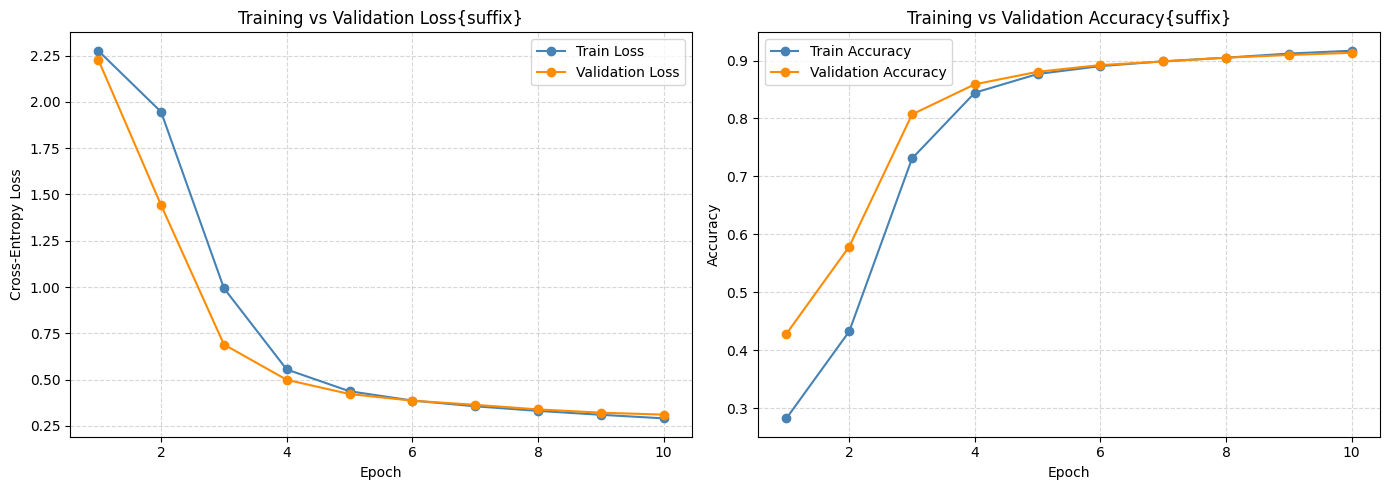

Plot saved → training_curves.png

--- Architecture: [512, 256, 128] ---
Epoch  0/10 | Train Loss: 2.2778  Acc: 0.2967 | Val Loss: 2.2341  Acc: 0.4489
Epoch  1/10 | Train Loss: 1.9558  Acc: 0.5194 | Val Loss: 1.3529  Acc: 0.6687
Epoch  2/10 | Train Loss: 0.8569  Acc: 0.7690 | Val Loss: 0.6248  Acc: 0.8190
Epoch  3/10 | Train Loss: 0.5313  Acc: 0.8475 | Val Loss: 0.4840  Acc: 0.8620
Epoch  4/10 | Train Loss: 0.4367  Acc: 0.8752 | Val Loss: 0.4234  Acc: 0.8737
Epoch  5/10 | Train Loss: 0.3883  Acc: 0.8884 | Val Loss: 0.3844  Acc: 0.8884
Epoch  6/10 | Train Loss: 0.3539  Acc: 0.8985 | Val Loss: 0.3532  Acc: 0.8975
Epoch  7/10 | Train Loss: 0.3272  Acc: 0.9061 | Val Loss: 0.3329  Acc: 0.9036
Epoch  8/10 | Train Loss: 0.3046  Acc: 0.9124 | Val Loss: 0.3117  Acc: 0.9110
Epoch  9/10 | Train Loss: 0.2845  Acc: 0.9181 | Val Loss: 0.2917  Acc: 0.9172


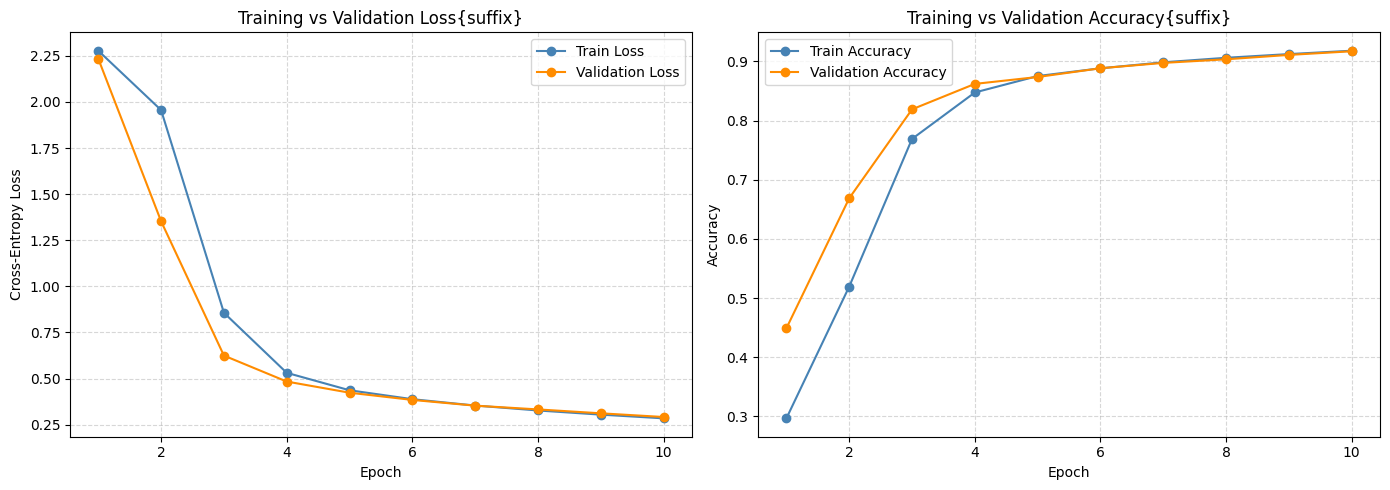

Plot saved → training_curves.png
{'[64, 32, 16]': 0.899, '[128, 64, 32]': 0.9039166666666667, '[256, 128, 64]': 0.9133333333333333, '[512, 256, 128]': 0.9171666666666667}


In [ ]:
def experiment_neurons(configs, label="neurons"):
    results = {}

    for sizes in configs:
        label_str = str(sizes)
        print(f"\n--- Architecture: {label_str} ---")

        model = CustomNet(sizes)
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)
        plot_history(history, title_suffix=f"Arch {label_str}")

        results[label_str] = history["val_acc"][-1]

    return results

configs = [[64, 32, 16], [128, 64, 32], [256, 128, 64], [512, 256, 128]]
neuron_results = experiment_neurons(configs, label="width")

print(neuron_results)


## Best Model — Final Evaluation on Test Set

Epoch  9/10 | Train Loss: 0.1697  Acc: 0.9511 | Val Loss: 0.1933  Acc: 0.9425


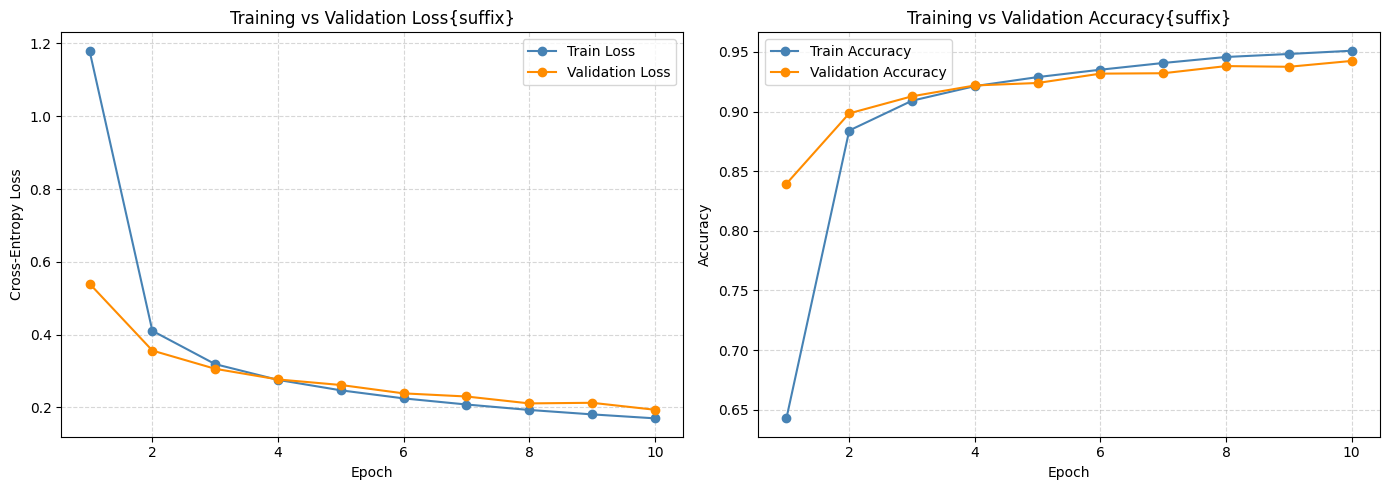

Plot saved → training_curves.png
Test Accuracy: 0.9464


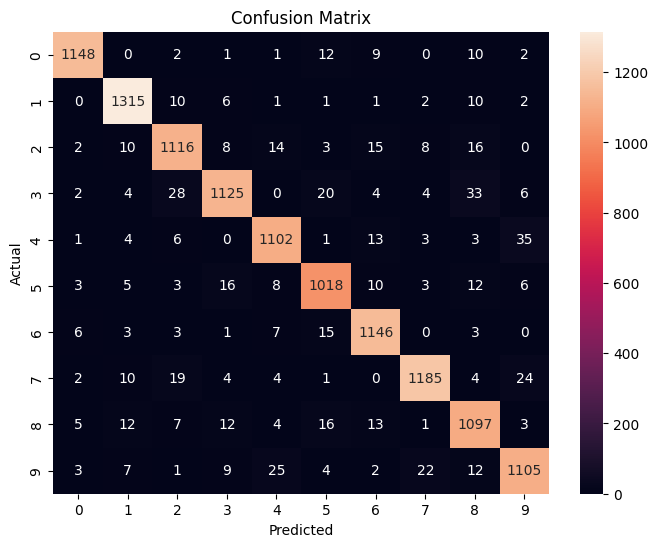

In [ ]:
# Train the best model configuration and evaluate it on test data.
best_model = digit_recognition()
history = best_model.training_step(train_dataloader, val_dataloader, epochs=10, lr=0.01)

plot_history(history)

test_acc = evaluate_on_test(best_model, test_dataloader)

## Bonus Part - Convolutional Neural Network (CNN)
In this part we will implement same functionality with different architecture. The CNN architecture enhance the model for the following: 
- If a digit get shifted a little, model still recognise it
- Significantly reduce the number of parameters
- CNNs treat images like structured visual data

In [30]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Transform: convert to tensor only (NO flattening)
transform = transforms.ToTensor()

# Load dataset
full_dataset = datasets.MNIST(root='mnist_train', train=True, download=True, transform=transform)

# Split: 60% train, 20% val, 20% test
total_size = len(full_dataset)
train_size = int(0.6 * total_size)
val_size   = int(0.2 * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

100.0%
100.0%
100.0%
100.0%


In [27]:
class CNN_Digit_Recognition(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Input: (1, 28, 28)
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # → (16, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # → (16, 14, 14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # → (32, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # → (32, 7, 7)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                # → (32*7*7 = 1568)
            nn.Linear(1568, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 10)
        )

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def training_step(self, train_dataloader, val_dataloader, epochs, lr=0.01):
        optimizer = optim.SGD(self.parameters(), lr=lr)

        history = {"train_loss": [], "val_loss": [],
                   "train_acc": [], "val_acc": []}

        for epoch in range(epochs):

            # Training
            self.train()
            running_loss, correct, total = 0.0, 0, 0

            for images, labels in train_dataloader:
                optimizer.zero_grad()

                outputs = self(images)   # (batch, 1, 28, 28)
                loss = self.loss_fn(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * labels.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_loss = running_loss / total
            train_acc = correct / total

            # Validation
            self.eval()
            val_loss_sum, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for images, labels in val_dataloader:
                    outputs = self(images)
                    loss = self.loss_fn(outputs, labels)

                    val_loss_sum += loss.item() * labels.size(0)
                    preds = outputs.argmax(dim=1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            val_loss = val_loss_sum / val_total
            val_acc = val_correct / val_total

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        return history

Epoch 1/20 | Train Loss: 0.5457 Acc: 0.8727 | Val Loss: 0.1268 Acc: 0.9661
Epoch 2/20 | Train Loss: 0.1558 Acc: 0.9637 | Val Loss: 0.0829 Acc: 0.9768
Epoch 3/20 | Train Loss: 0.1124 Acc: 0.9725 | Val Loss: 0.0724 Acc: 0.9789
Epoch 4/20 | Train Loss: 0.0902 Acc: 0.9778 | Val Loss: 0.0606 Acc: 0.9818
Epoch 5/20 | Train Loss: 0.0791 Acc: 0.9797 | Val Loss: 0.0576 Acc: 0.9833
Epoch 6/20 | Train Loss: 0.0639 Acc: 0.9842 | Val Loss: 0.0574 Acc: 0.9836
Epoch 7/20 | Train Loss: 0.0590 Acc: 0.9849 | Val Loss: 0.0609 Acc: 0.9841
Epoch 8/20 | Train Loss: 0.0532 Acc: 0.9867 | Val Loss: 0.0596 Acc: 0.9828
Epoch 9/20 | Train Loss: 0.0472 Acc: 0.9866 | Val Loss: 0.0705 Acc: 0.9819
Epoch 10/20 | Train Loss: 0.0443 Acc: 0.9879 | Val Loss: 0.0510 Acc: 0.9857
Epoch 11/20 | Train Loss: 0.0405 Acc: 0.9892 | Val Loss: 0.0494 Acc: 0.9872
Epoch 12/20 | Train Loss: 0.0370 Acc: 0.9904 | Val Loss: 0.0479 Acc: 0.9872
Epoch 13/20 | Train Loss: 0.0339 Acc: 0.9913 | Val Loss: 0.0541 Acc: 0.9853
Epoch 14/20 | Train L

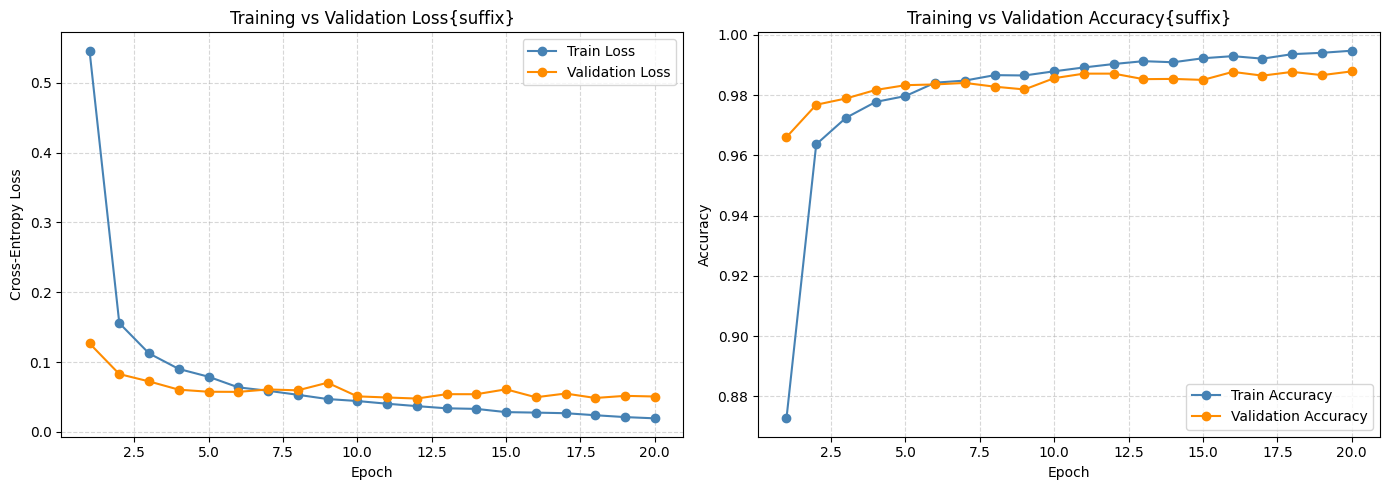

Plot saved → CNN_training_curves.png


In [ ]:
def plot_history(history , title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Loss plot —
    ax1.plot(epochs, history["train_loss"], label="Train Loss",      color="steelblue",  marker="o")
    ax1.plot(epochs, history["val_loss"],   label="Validation Loss", color="darkorange", marker="o")
    ax1.set_title("Training vs Validation Loss{suffix}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
 
    # — Accuracy plot —
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy",      color="steelblue",  marker="o")
    ax2.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="darkorange", marker="o")
    ax2.set_title("Training vs Validation Accuracy{suffix}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)
 
    plt.tight_layout()
    plt.savefig("CNN_training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → CNN_training_curves.png")
 
 
# ─────────────────────────────────────────────
# 6. RUN EVERYTHING
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model   = CNN_Digit_Recognition()
    history = model.training_step( train_loader, val_loader, epochs=20, lr=0.01)
    plot_history(history )